# Case study 3: 20 DOF = 5 x 4-DOF

Five 4-DOF subsystems, an unknown mass estimated with an EKF, a stiffness and a damping identified from a single displacement sensor with a CKF, and the El Centro ground-motion record (stretched to the horizon) as the force on the last mass.

The chain has non-uniform masses, stiffnesses and dampings, random forces act on
every mass, and messages are mean interface forces exchanged with the
**gauss-seidel** schedule. The measurement covariance is inflated
10x to account for the message error (see [Concepts](../concepts.md)).

The paper-length horizon is 20 s at 1 ms; set `PCI_T` to shorten it. Set
`RUN_CENTRAL = True` to also run a single UKF on the full augmented state for
comparison.

In [1]:
import os

from _support import ELCENTRO, build, centralized, compare_with_yaml, print_design, report

N_DOF = 20
PARTITION = [[1, 2, 3, 4], [5, 6, 7, 8], [9, 10, 11, 12], [13, 14, 15, 16], [17, 18, 19, 20]]
NAMES = ['S1', 'S2', 'S3', 'S4', 'S5']
SCHEDULE = "gauss_seidel"
DT, T = 1e-3, float(os.environ.get("PCI_T", 20.0))
R_INFLATION = 10.0     # R = (10 x sensor noise)^2, needed with mean-only messages
RUN_CENTRAL = False

## Design: one line per subsystem

Filter, integrator, sensors with their noise standard deviation, and the unknowns as
a fraction of the true value used for the initial guess.

In [2]:
DESIGN = [
    dict(filter='kf', integrator='heun', sensors={'a2': 0.005, 'a4': 0.005}, unknowns={}),  # grounded: accelerations only, states only
    dict(filter='ukf', integrator='heun', sensors={'x6': 0.001, 'a8': 0.01}, unknowns={'k7': 0.7}),  # displacement + acceleration
    dict(filter='ckf', integrator='heun', sensors={'x11': 0.001}, unknowns={'k10': 0.6, 'c10': 1.5}),  # a single displacement sensor, two unknowns
    dict(filter='ekf', integrator='rk4', sensors={'x14': 0.0001, 'a16': 0.005}, unknowns={'m15': 0.8}),  # unknown mass, EKF, RK4
    dict(filter='ukf', integrator='heun', sensors={'a18': 0.02, 'x20': 0.001}, unknowns={'k19': 1.3}),  # noisy accelerometer + displacement
]
LOADS = {d: {"type": "random", "std": 300.0, "seed": 30 + d} for d in range(1, N_DOF)}
LOADS[N_DOF] = {"type": "elcentro", "path": ELCENTRO, "scale": 1500.0, "stretch": True}

## Physical system, synthetic data, decomposition

In [3]:
chain, truth_dict, data, system, unknowns, sensors, noise = build(N_DOF, PARTITION, NAMES, DESIGN, LOADS, DT, T, SCHEDULE, R_INFLATION)
print_design("20 DOF = 5 x 4-DOF", NAMES, PARTITION, DESIGN, DT, T, SCHEDULE, R_INFLATION)

20 DOF = 5 x 4-DOF   schedule = gauss_seidel   dt = 0.001   T = 20.0 s   steps = 20000   R inflation = 10x
----------------------------------------------------------------------------------------------------
subsystem DOFs              filter  integrator  task                      sensors (noise std)                     
S1        [1, 2, 3, 4]      kf      heun        state estimation          a2 (0.005), a4 (0.005)                  
S2        [5, 6, 7, 8]      ukf     heun        joint: k7                 x6 (0.001), a8 (0.01)                   
S3        [9, 10, 11, 12]   ckf     heun        joint: k10, c10           x11 (0.001)                             
S4        [13, 14, 15, 16]  ekf     rk4         joint: m15                x14 (0.0001), a16 (0.005)               
S5        [17, 18, 19, 20]  ukf     heun        joint: k19                a18 (0.02), x20 (0.001)                 


## Distributed estimation

In [4]:
res = system.estimate(data, loads={f"f{d}": v for d, v in LOADS.items()}, dt=DT, T=T, truth=truth_dict)
report(res, chain.parameters, unknowns, NAMES, PARTITION, T)

Distributed run time: 23.9 s (sequential; ~4.8 s with one core per subsystem)

parameter       true   initial       final  error %  post. std
k7           53988.7   37792.1     52924.1    -1.97        194
k10          55252.1   33151.3     55901.4    +1.18   1.24e+03
c10            218.0     327.0       300.6   +37.87       76.9
m15            476.2     381.0       481.4    +1.10       1.07
k19          44758.0   58185.4     44761.2    +0.01        100

subsystem   disp. NRMSE (2nd half)   vel. NRMSE (2nd half)
S1                          0.245%                  0.182%
S2                          0.269%                  0.279%
S3                          0.185%                  0.213%
S4                          0.102%                  0.142%
S5                          0.121%                  0.051%
interface-force NRMSE (2nd half): F_k5 0.19%, F_k9 0.22%, F_k13 0.17%, F_k17 0.10%


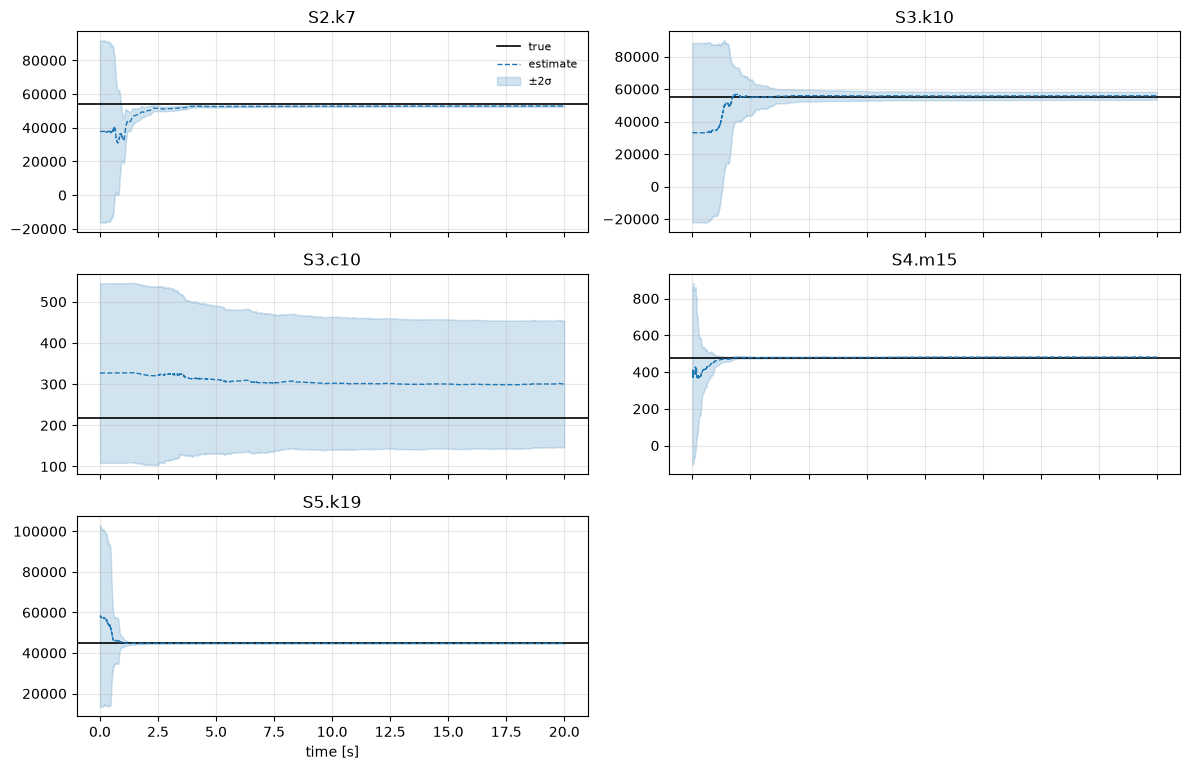

In [5]:
res.plot_parameters();

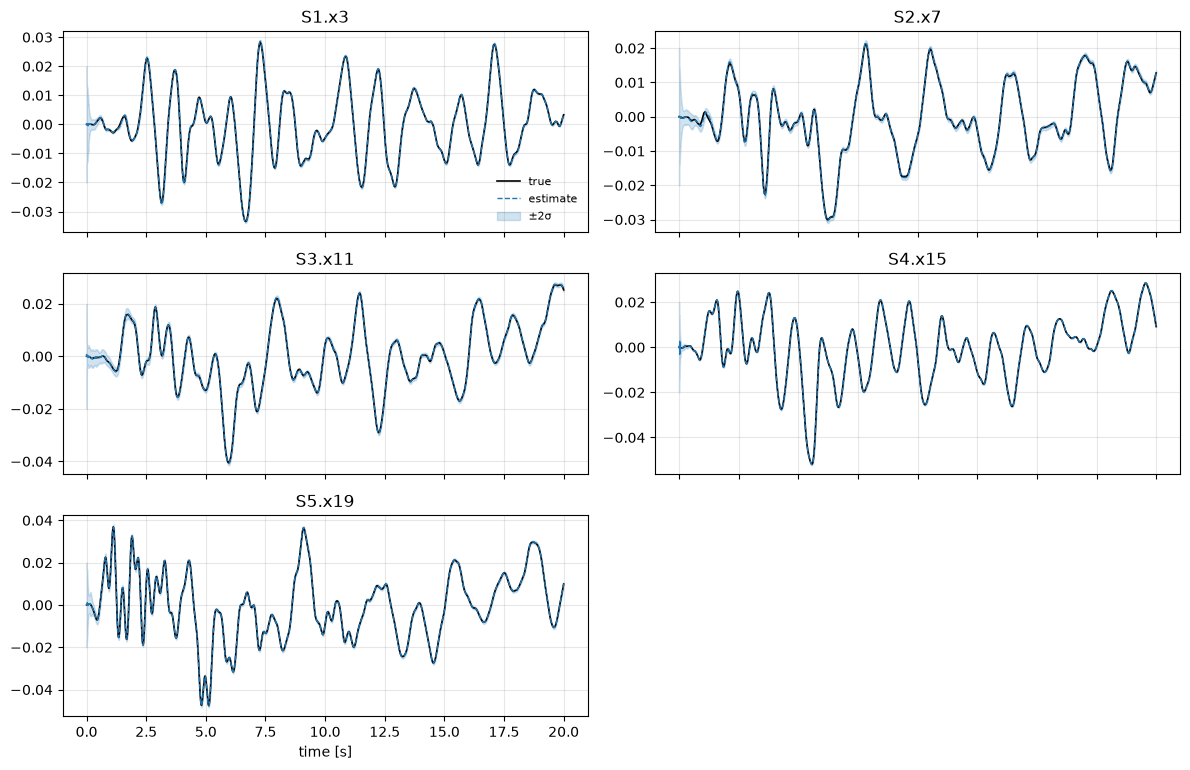

In [6]:
res.plot_states([f"{name}.x{g[len(g) // 2]}" for name, g in zip(NAMES, PARTITION)][:6]);

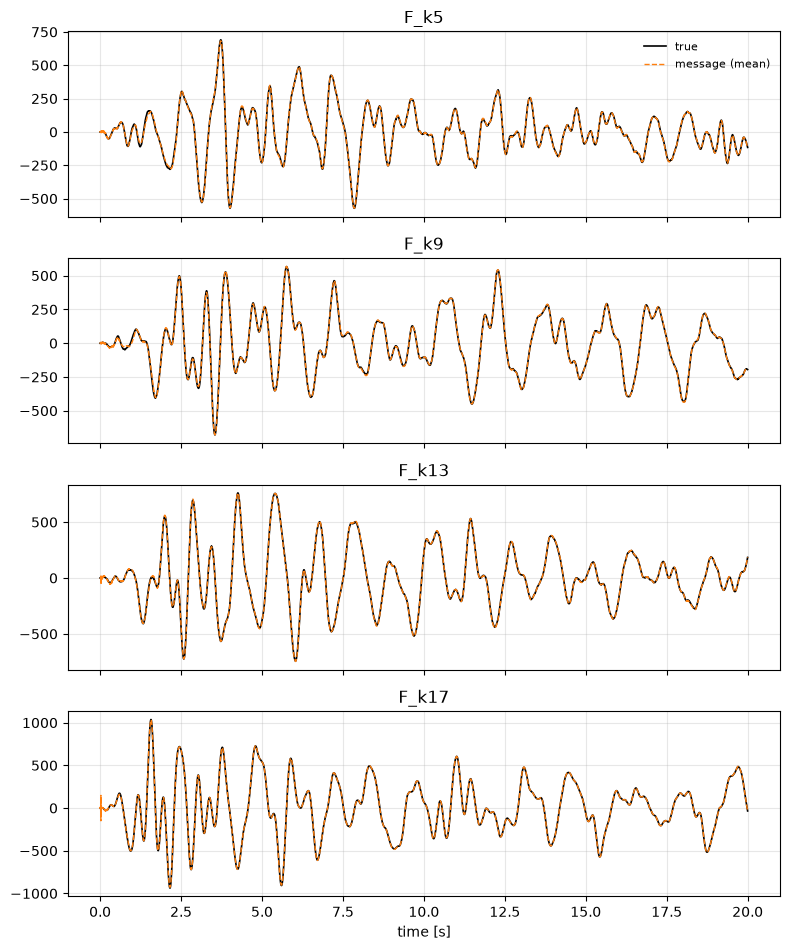

In [7]:
res.plot_messages();

## Centralized comparison (optional)

In [8]:
if RUN_CENTRAL:
    centralized(chain, N_DOF, unknowns, sensors, noise, data, LOADS, DT, T, truth_dict, R_INFLATION, res)

## The YAML twin

`03_case_20dof.yaml` describes the identical problem; with the full 20 s horizon it
reproduces the Python-API result to machine precision.

In [9]:
if T == 20.0:
    compare_with_yaml(res, "03_case_20dof.yaml", unknowns)

YAML twin (03_case_20dof.yaml): k7=52924.1, k10=55901.4, c10=300.6, m15=481.4, k19=44761.2   max relative difference to Python API: 0.00e+00


Gauss-Seidel gives the same parameter estimates as Jacobi at the same cost per step. The damping c10, identified next to a single accelerometer, converges slowly; dampings need long records or a displacement sensor, as in the paper's 6-DOF study.